In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# imports for time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/cleaned data.csv')
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_rows", 100)
df.head()
df.drop(['Unnamed: 0'],axis=1, inplace=True) # drop additionaal non needed column
df.keys()
df['mod_zcta']=df['mod_zcta'].astype(str)
df['date']=pd.to_datetime(df['date'])
df.dtypes # check data types

extract_date                  object
date                  datetime64[ns]
mod_zcta                      object
total_ed_visits                int64
ili_pne_visits                 int64
ili_pne_admissions             int64
dtype: object

In [5]:
# Checking for gaps in the date column
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = date_range.difference(df['date'].unique())
print(f"Total unique dates in df: {df['date'].nunique()}")
print(f"Expected days in range: {len(date_range)}")
if len(missing_dates) > 0:
    for d in missing_dates:
        print(f"  {d.date()}")
else:
    print("  No gaps found — all dates are present.") 

Total unique dates in df: 866
Expected days in range: 866
  No gaps found — all dates are present.


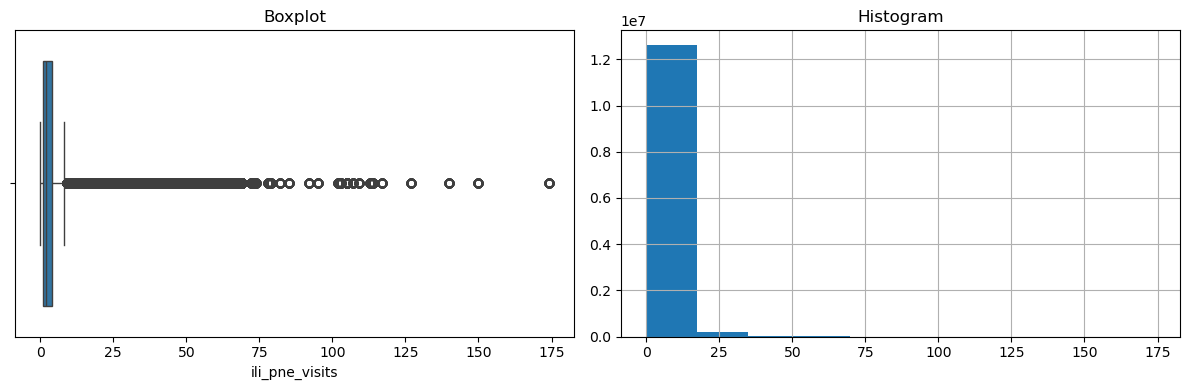

In [6]:
# Boxplot and Histogram for ili_pne_visits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(df, x='ili_pne_visits', ax=axes[0])
axes[0].set_title('Boxplot')
df['ili_pne_visits'].hist(ax=axes[1])
axes[1].set_title('Histogram')
plt.tight_layout()
plt.show()

In [7]:
# I Picked one zipcode to demo the full pipeline
zip_code = df['mod_zcta'].value_counts().index[0]
print(f"Selected zipcode: {zip_code}")

# Filter to that zipcode, aggregate monthly
ts = df[df['mod_zcta'] == zip_code].groupby('date')['ili_pne_visits'].sum()
ts = ts.resample('MS').sum()  # monthly start frequency
print(f"Shape: {ts.shape}")
ts.head()

Selected zipcode: 11365
Shape: (29,)


date
2020-03-01    14535
2020-04-01    11475
2020-05-01     2210
2020-06-01     1105
2020-07-01     1870
Freq: MS, Name: ili_pne_visits, dtype: int64

In [42]:
ts.describe()
ts.head()

date
2020-03-01    14535
2020-04-01    11475
2020-05-01     2210
2020-06-01     1105
2020-07-01     1870
Freq: MS, Name: ili_pne_visits, dtype: int64

<Axes: xlabel='date'>

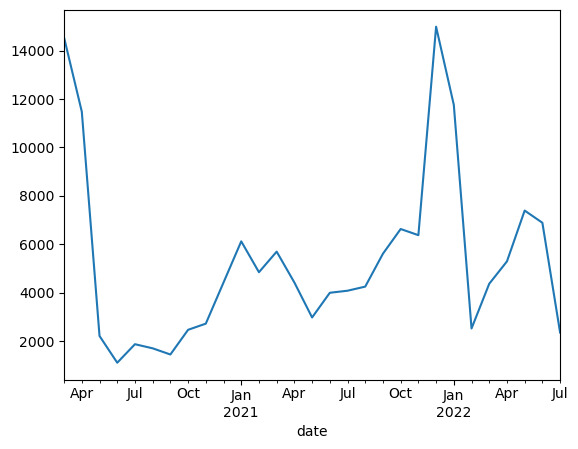

In [43]:
ts.plot()

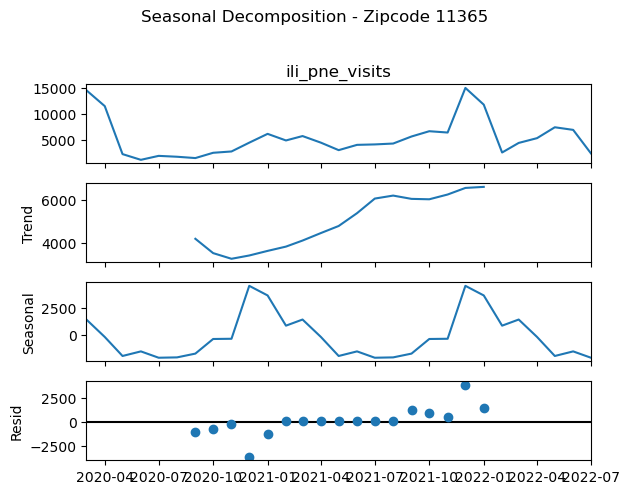

In [8]:
# Step 1: Decompose the time series to visualize trend, seasonality, residuals
decomp = seasonal_decompose(ts, model='additive', period=12)
decomp.plot()
plt.suptitle(f'Seasonal Decomposition - Zipcode {zip_code}', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Step 2: Check stationarity with ADF test
result = adfuller(ts)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("Result: Stationary (reject null hypothesis)")
else:
    print("Result: Non-stationary (fail to reject null hypothesis)")

ADF Statistic: -4.1904
p-value: 0.0007
Result: Stationary (reject null hypothesis)


In [18]:
# Step 3: Log transform + differencing (if needed to achieve stationarity)
ts_log = np.log1p(ts)  # log(1+x) to handle zeros
ts_diff = ts_log.diff().dropna()

# Verify differenced series is stationary
result_diff = adfuller(ts_diff)
print(f"ADF after log + diff — p-value: {result_diff[1]:.4f}")
print("Stationary" if result_diff[1] < 0.05 else "Non-stationary")

ADF after log + diff — p-value: 0.0066
Stationary


In [12]:
# Step 4: Time-based train/test split (80/20)
split = int(len(ts) * 0.8)
train, test = ts[:split], ts[split:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

Train: 2020-03-01 to 2022-01-01 (23 months)
Test:  2022-02-01 to 2022-07-01 (6 months)


In [13]:
# Naive Baseline: predict last known training value for entire test period
naive_forecast = pd.Series(train.iloc[-1], index=test.index)
naive_mae = mean_absolute_error(test, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
print(f"Naive Baseline (last value = {train.iloc[-1]})")
print(f"  MAE:  {naive_mae:.2f}")
print(f"  RMSE: {naive_rmse:.2f}")

Naive Baseline (last value = 11760)
  MAE:  6958.00
  RMSE: 7224.73


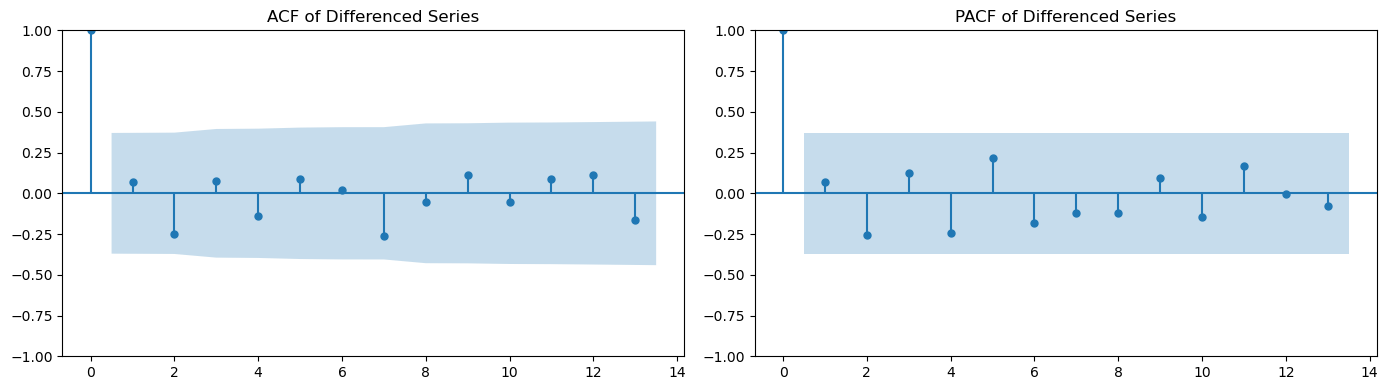

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use at most half the sample size for lags
max_lags = len(ts_diff) // 2 - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot — helps determine q (MA order)
plot_acf(ts_diff, lags=max_lags, ax=axes[0])
axes[0].set_title('ACF of Differenced Series')

# PACF plot — helps determine p (AR order)
plot_pacf(ts_diff, lags=max_lags, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Differenced Series')

plt.tight_layout()
plt.show()

In [38]:
# Step 5 & 6: Fit ARIMA model and forecast
model = ARIMA(train, order=(1, 0, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         ili_pne_visits   No. Observations:                   23
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -215.648
Date:                Thu, 02 Apr 2026   AIC                            439.295
Time:                        22:43:54   BIC                            443.837
Sample:                    03-01-2020   HQIC                           440.438
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5493.8854   2887.050      1.903      0.057    -164.628    1.12e+04
ar.L1          0.4100      0.464      0.884      0.377      -0.499       1.319
ma.L1          0.5217      0.398      1.311      0.1

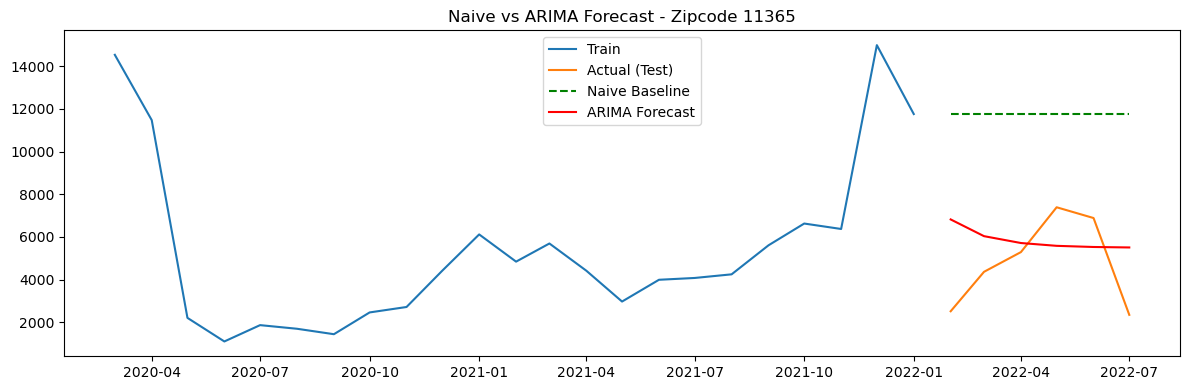

In [39]:
# Forecast on the test period
forecast = model_fit.forecast(steps=len(test))

# Plot actual vs forecast vs naive
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual (Test)')
plt.plot(test.index, naive_forecast, label='Naive Baseline', color='green', linestyle='--')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red')
plt.title(f'Naive vs ARIMA Forecast - Zipcode {zip_code}')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Step 7: Evaluation metrics — Naive vs ARIMA
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"Zipcode {zip_code} — Model Comparison")
print(f"  {'Model':<20} {'MAE':>8} {'RMSE':>8}")
print(f"  {'Naive Baseline':<20} {naive_mae:>8.2f} {naive_rmse:>8.2f}")
print(f"  {'ARIMA(1,0,1)':<20} {mae:>8.2f} {rmse:>8.2f}")

Zipcode 11365 — Model Comparison
  Model                     MAE     RMSE
  Naive Baseline        6958.00  7224.73
  ARIMA(1,0,1)          2119.75  2468.26
